In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# importing the csv file
df = pd.read_csv("Telco Customer Churn.csv")

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
# grouping the same data type columns
df.columns.to_series().groupby(df.dtypes).groups

{int64: ['SeniorCitizen', 'tenure'], float64: ['MonthlyCharges'], object: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']}

In [34]:
# exploring all the values of features
for elem in df.columns [1:]:
    print(df[elem].value_counts())
    print('\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


DeviceProtection
No                     3095
Yes       

In [44]:
df['TotalCharges'].value_counts()        

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [46]:
# preprocessing the TotalCharges, changing the null values with zero

df.loc[ df['TotalCharges'] == ' ', 'TotalCharges'] = 0
df["TotalCharges"] = df["TotalCharges"].astype("float64")

In [56]:
# checking the null values
df['TotalCharges'].isna().sum()

0

In [54]:
# preprocessing the senior citizens, converting the int64 to object
df['customerID'] = df['customerID'].astype('object')

In [58]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<Axes: xlabel='Churn'>

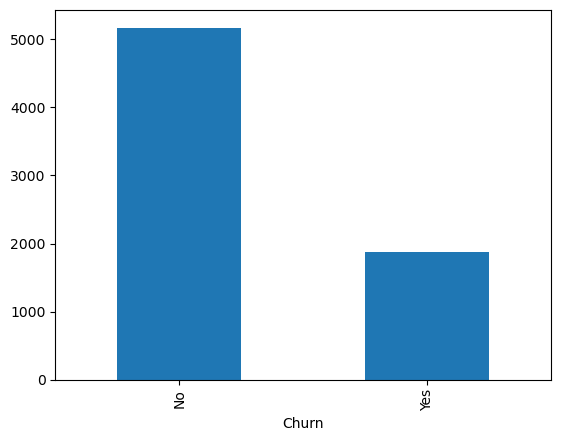

In [60]:
df['Churn'].value_counts().plot(kind = 'bar')

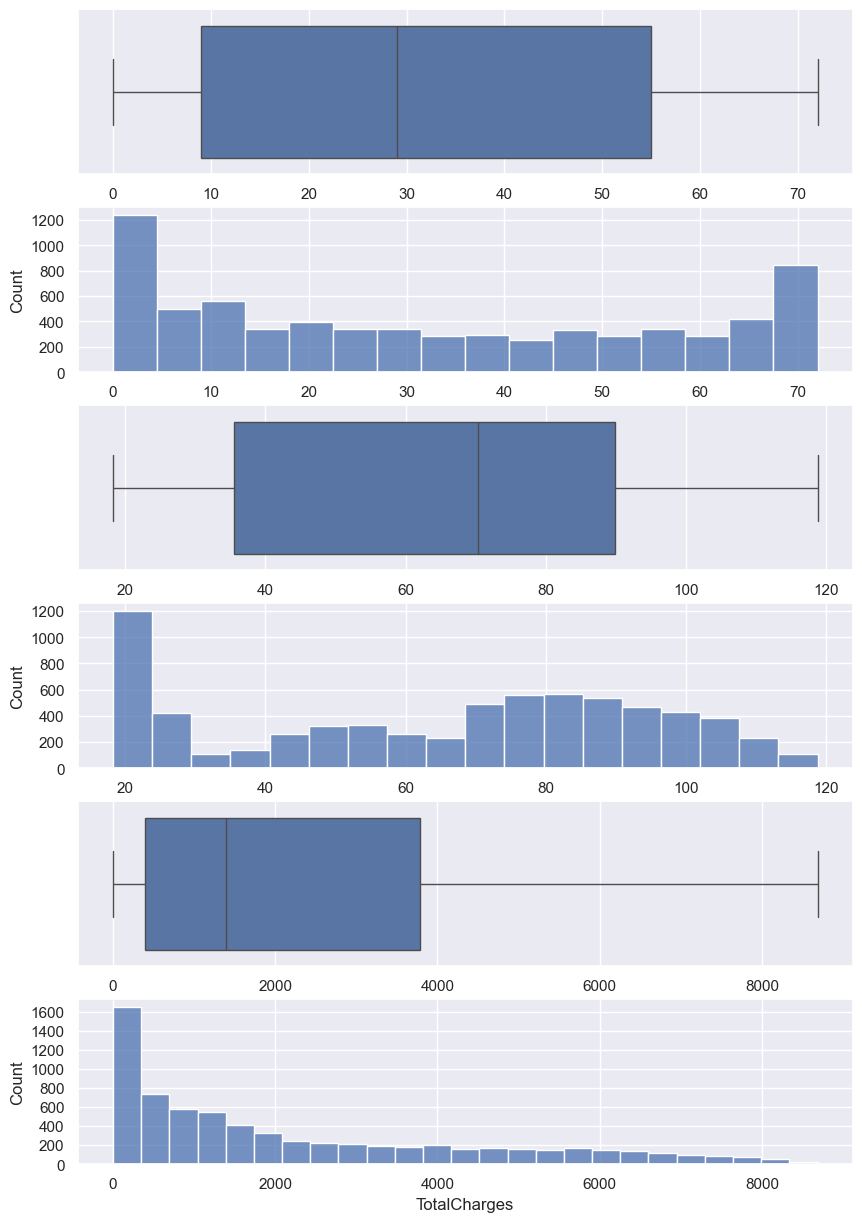

In [68]:
# exploring the numerical one by one
fig, ax = plt.subplots(6, figsize=(10, 15))
sns.set(font_scale=0.5)

g=sns.boxplot(data=df, x="tenure", ax=ax[0])
g=sns.histplot(data=df, x="tenure", ax=ax[1])


g=sns.boxplot(data=df, x="MonthlyCharges", ax=ax[2])
g=sns.histplot(data=df, x="MonthlyCharges", ax=ax[3])


g=sns.boxplot(data=df, x="TotalCharges", ax=ax[4])
g=sns.histplot(data=df, x="TotalCharges", ax=ax[5])

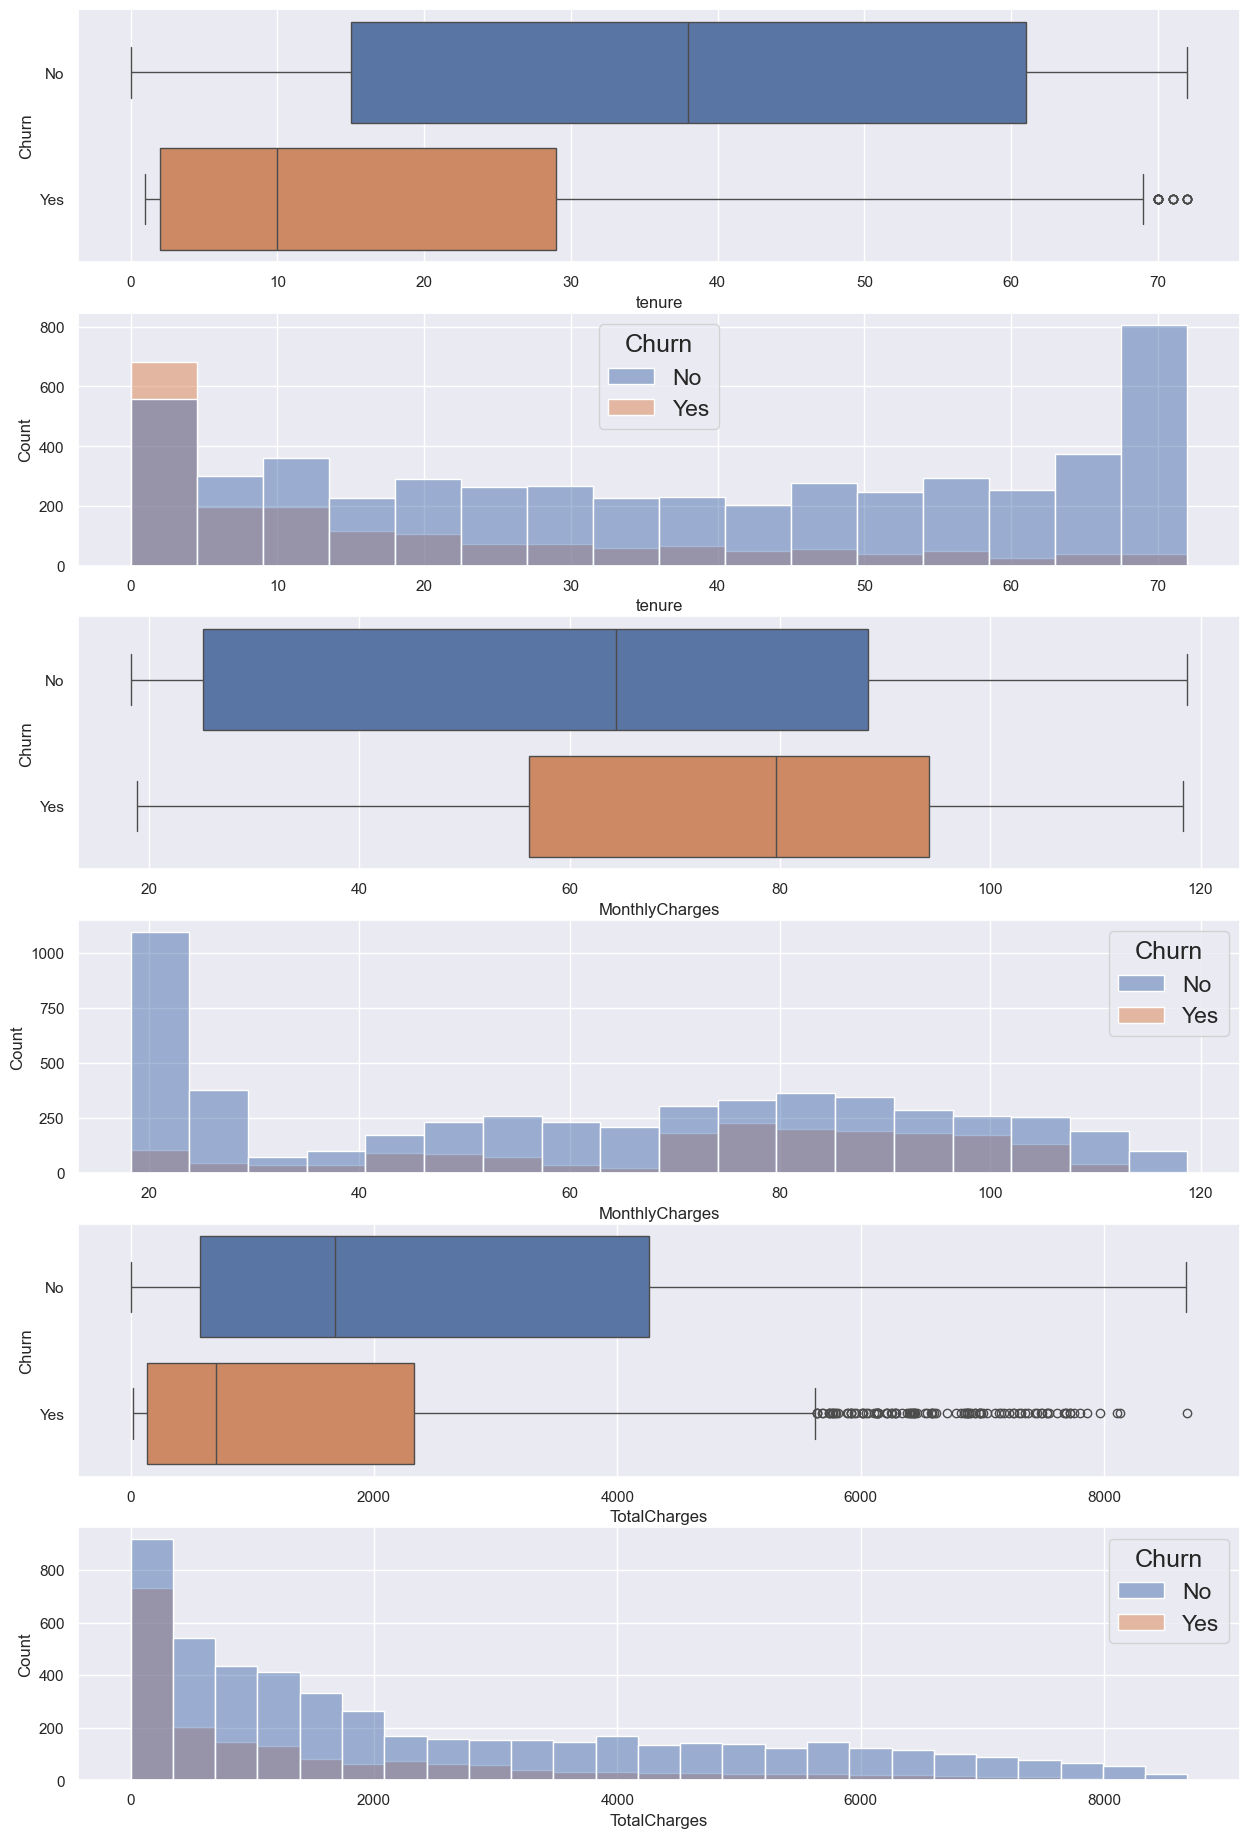

In [104]:
# exploring churn with other numerical variables
fig, ax = plt.subplots(6, figsize = (15,23))
sns.set(font_scale =1.5)

g = sns.boxplot(data = df, x= "tenure", y= "Churn", ax= ax[0], hue="Churn") 
g = sns.histplot(data = df,x= "tenure", ax=ax[1], hue= "Churn")

g = sns.boxplot(data = df, x= "MonthlyCharges", y= "Churn", ax=ax[2], hue= "Churn")
g = sns.histplot(data = df, x= "MonthlyCharges",ax= ax[3], hue="Churn")

g = sns.boxplot(data = df, x= "TotalCharges", y= "Churn", ax=ax[4], hue= "Churn")
g = sns.histplot(data = df, x= "TotalCharges",ax= ax[5], hue="Churn")

In [138]:
# exploring the categorial vaiables
categorical_variables = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']


In [144]:
# converting the categorical features (non numeric) - one hot encoding
df_dummies = pd.get_dummies(df[categorical_variables])

# adding the numerical values
df_dummies[['tenure', 'MonthlyCharges', 'TotalCharges']] = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

df_dummies['Churn']= df['Churn']
df_dummies['Churn'] = df_dummies['Churn'].map({'No': 0, 'Yes': 1})
df_dummies.tail()

,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,...,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges,Churn
7038,0,False,True,False,True,False,True,False,True,False,...,False,True,False,False,False,True,24,84.80,1990.50,0
7039,0,True,False,False,True,False,True,False,True,False,...,False,True,False,True,False,False,72,103.20,7362.90,0
7040,0,True,False,False,True,False,True,True,False,False,...,False,True,False,False,True,False,11,29.60,346.45,0
7041,1,False,True,False,True,True,False,False,True,False,...,False,True,False,False,False,True,4,74.40,306.60,1
7042,0,False,True,True,False,True,False,False,True,True,...,False,True,True,False,False,False,66,105.65,6844.50,0


<Axes: >

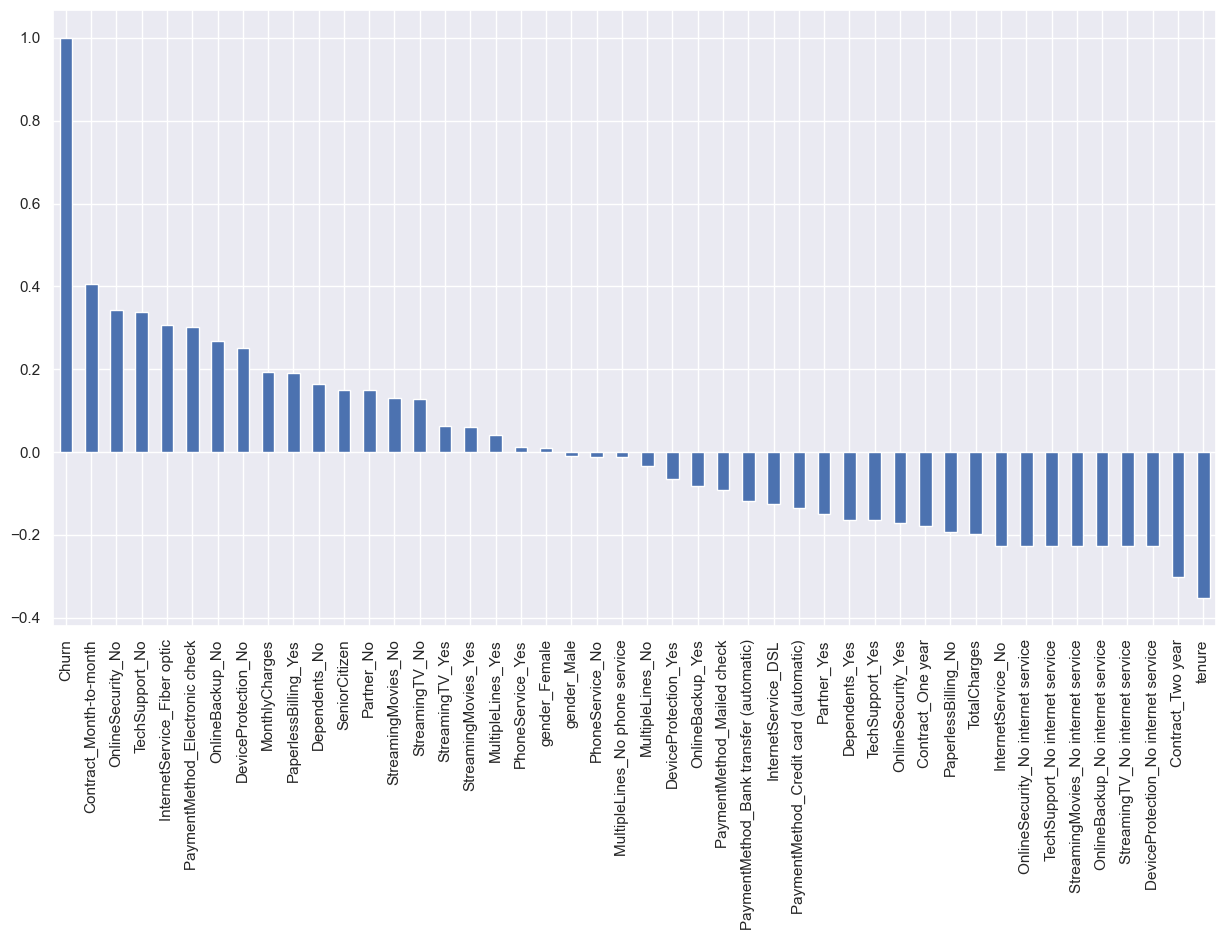

In [150]:
#Get Correlation of "Churn" with other variables:
sns.set(font_scale=1)
plt.figure(figsize=(15,8))
df_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

<Axes: >

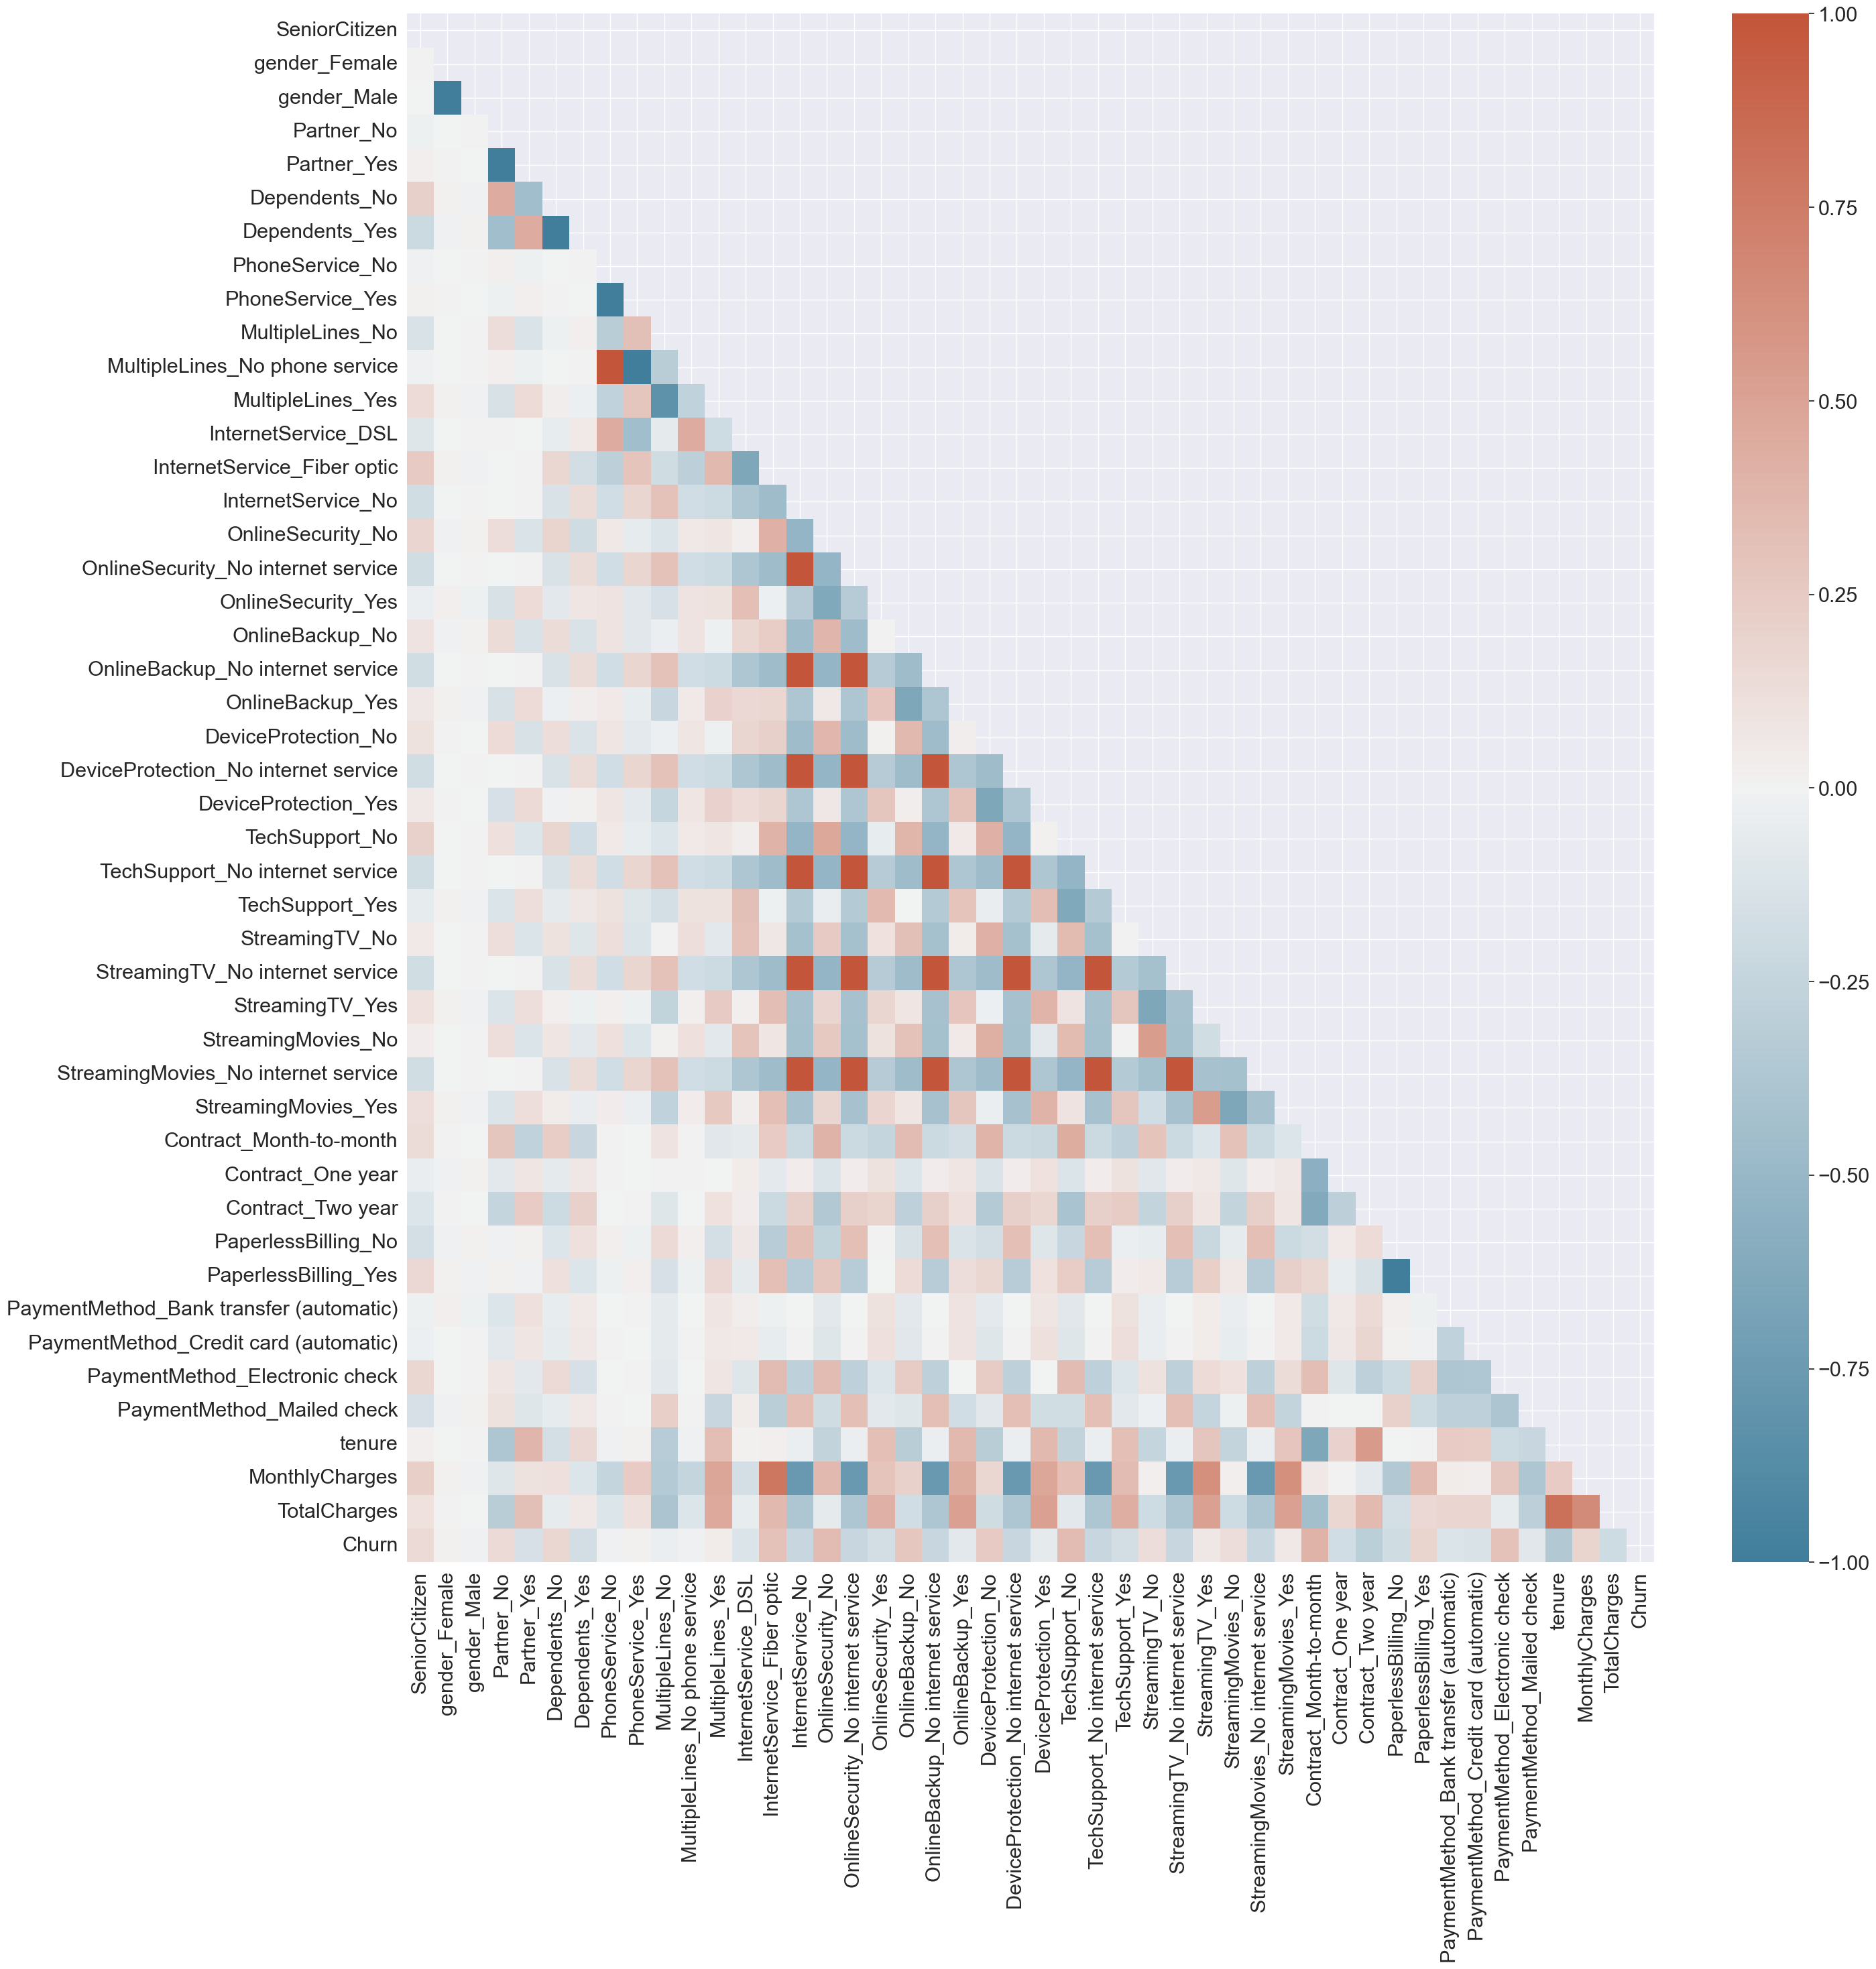

In [152]:
sns.set(font_scale=2)
fig, ax = plt.subplots(figsize=(30,30))

# Generating a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

mask = np.triu(np.ones_like(df_dummies.corr(), dtype=bool))
sns.heatmap(df_dummies.corr(), mask=mask, cmap=cmap)

In [154]:
# machine learning models

In [158]:
#prepare for model training
train_columns = df.columns.to_list()

for elem in ["customerID","Churn"]:
    train_columns.remove(elem)

In [164]:
# converting the categorical features
df_dummies = pd.get_dummies(df[categorical_variables])

# adding the numerical features
df_dummies[['tenure', 'MonthlyCharges', 'TotalCharges']] = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

df_dummies['Churn'] = df['Churn']
df_dummies['Churn'] = df_dummies['Churn'].map({'No': 0, 'Yes': 1})


y = df_dummies['Churn']
X = df[train_columns].copy()


from sklearn.preprocessing import LabelEncoder

for col in train_columns:

    le = LabelEncoder()
    le.fit(X[col].to_list())
    X.loc[:, col] = le.transform(X[col])


clf_stats_df = pd.DataFrame(columns=["clf_name", "F1-score", "auc-score", "elapsed_time"])
roc_auc_score_list = []

In [174]:
# logistic regression
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import time
import seaborn as sns


# splittig data for train test 
xtrain, xtest, ytrain, ytest = train_test_split(X, y, random_state=42, test_size=0.2, stratify = y)

from sklearn.linear_model import LogisticRegression

start_time = time.time()

predictions_probas_list = np.zeros([len(yvalid), 2])



roc_auc_list = []
num_of_folds = 10
num_fold = 0

#feature_importance_df = pd.DataFrame()

folds = StratifiedKFold(n_splits=num_of_folds, shuffle=False)

for train_index, test_index in folds.split(xtrain, ytrain):
    xtrain_stra, xtest_stra = xtrain.iloc[train_index,:], xtrain.iloc[test_index,:]
    ytrain_stra, ytest_stra = ytrain.iloc[train_index], ytrain.iloc[test_index]

    print()
    print("Stratified Fold:", num_fold)
    num_fold = num_fold + 1
    print()

    clf_stra_logit = LogisticRegression(random_state=42, max_iter=5000)

    clf_stra_logit.fit(xtrain_stra, ytrain_stra)


    predictions = clf_stra_logit.predict(xtest)
    predictions_probas = clf_stra_logit.predict_proba(xtest)
    predictions_probas_list += predictions_probas/num_of_folds

    roc_auc_list.append(roc_auc_score(ytest, predictions_probas[:,1], average = "macro"))


predictions = np.argmax(predictions_probas_list, axis=1)
roc_auc_score_list.append(roc_auc_list)

print()
print(classification_report(ytest, predictions))

print()
print("f1_score", f1_score(ytest, predictions, average = "macro"))

print()
print("roc_auc_score", roc_auc_score(ytest, predictions_probas_list[:,1], average = "macro"))

elapsed_time = time.time() - start_time
clf_stats_df = pd.concat([clf_stats_df, pd.DataFrame([{"clf_name": "clf_stra_logit",
                     "F1-score":f1_score(ytest, predictions, average = "macro"),
                     "auc-score": roc_auc_score(ytest, predictions_probas_list[:,1], average = "macro"),
                     "elapsed_time": elapsed_time}])], ignore_index=True)

print()
print("elapsed time in seconds: ", elapsed_time)
print()
import gc
gc.collect();


Stratified Fold: 0


Stratified Fold: 1


Stratified Fold: 2


Stratified Fold: 3


Stratified Fold: 4


Stratified Fold: 5


Stratified Fold: 6


Stratified Fold: 7


Stratified Fold: 8


Stratified Fold: 9


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409


f1_score 0.7301857900831302

roc_auc_score 0.8425275775659408

elapsed time in seconds:  9.512752056121826

